Results directory: /Users/ashleyrazo/Desktop/Thesis/biased-urn-stopping/results
Files found: 10
Total rows: 3000
   review_id  run_id     N  true_K  confidence  stop_n_bayes  \
0          9      53  7216     583        0.90          6929   
1          9      53  7216     583        0.95          6947   
2          9      53  7216     583        0.99          6980   
3          9      19  7216     583        0.90          6929   
4          9      19  7216     583        0.95          6947   

   true_recall_bayes  stop_n_baseline  true_recall_baseline  
0                1.0             3535              0.986278  
1                1.0             3616              0.986278  
2                1.0             3798              0.986278  
3                1.0             3499              0.989708  
4                1.0             3581              0.989708  

SUMMARY TABLE:

   confidence  miss_rate_bayes  miss_rate_baseline  mean_work_saved_bayes  \
0        0.90            0.015      

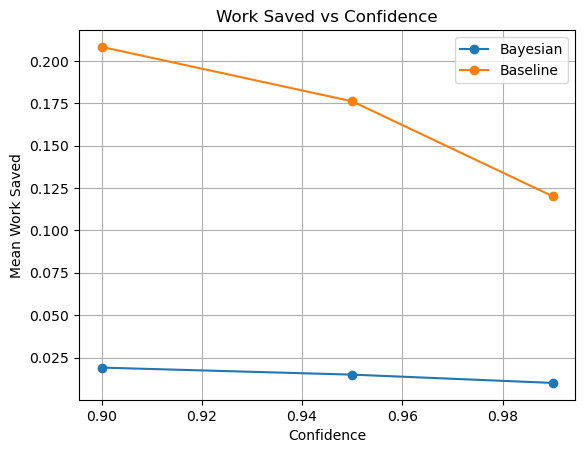

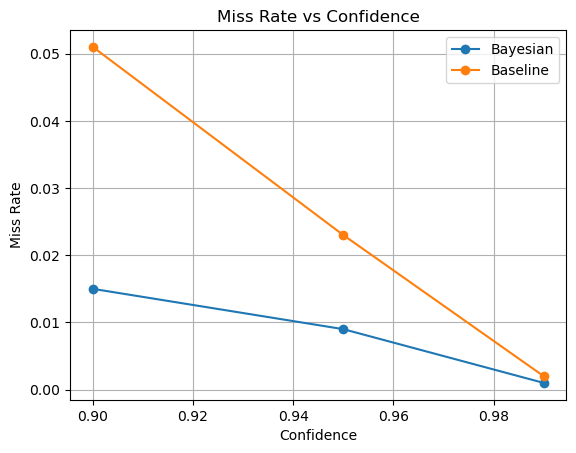

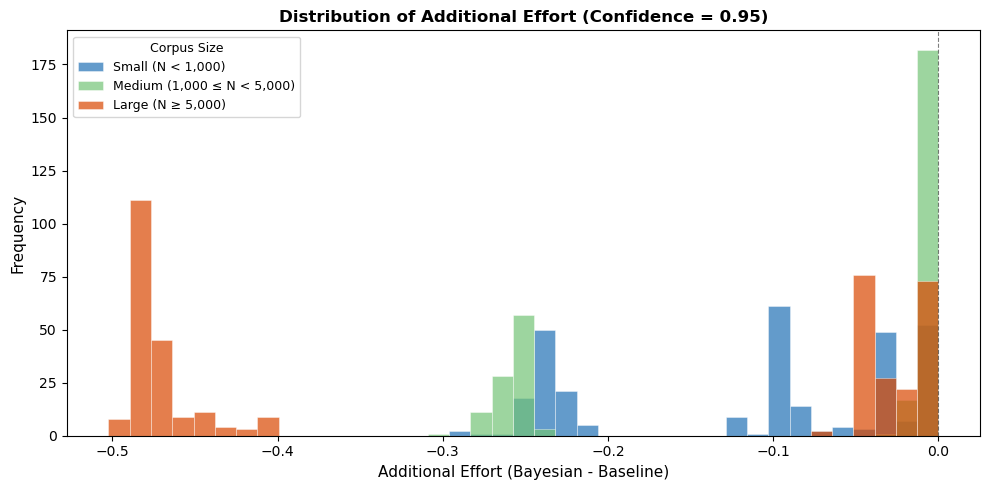

Saved: plot_additional_effort_hist.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os 
#Load and combine data


# Walk up from current directory to find the results folder
current = os.getcwd()

# Go up one level from results_csv to biased-urn-stopping
parent = os.path.dirname(current)

# Point to results folder
results_dir = os.path.join(parent, "results")

files = glob(os.path.join(results_dir, "results_review_*.csv"))

print("Results directory:", results_dir)
print("Files found:", len(files))

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Total rows:", len(df))
print(df.head())


#Define metrics

RECALL_TARGET = 0.95

# Miss indicators
df["miss_bayes"] = df["true_recall_bayes"] < RECALL_TARGET
df["miss_baseline"] = df["true_recall_baseline"] < RECALL_TARGET

# Work saved
df["work_saved_bayes"] = 1 - df["stop_n_bayes"] / df["N"]
df["work_saved_baseline"] = 1 - df["stop_n_baseline"] / df["N"]

# Additional effort (Bayes - Baseline)
df["additional_effort"] = df["work_saved_bayes"] - df["work_saved_baseline"]

df[df['confidence'] == 0.95].groupby('review_id')['additional_effort'].mean()


#summary table 

summary = df.groupby("confidence").agg(
    miss_rate_bayes=("miss_bayes", "mean"),
    miss_rate_baseline=("miss_baseline", "mean"),
    mean_work_saved_bayes=("work_saved_bayes", "mean"),
    mean_work_saved_baseline=("work_saved_baseline", "mean"),
    mean_additional=("additional_effort", "mean"),
    median_additional=("additional_effort", "median")
).reset_index()

print("\nSUMMARY TABLE:\n")
print(summary)

#Save summary
summary.to_csv("summary_results.csv", index=False)


#Plot 1 — work saved

plt.figure()
plt.plot(summary["confidence"], summary["mean_work_saved_bayes"], marker='o', label="Bayesian")
plt.plot(summary["confidence"], summary["mean_work_saved_baseline"], marker='o', label="Baseline")
plt.xlabel("Confidence")
plt.ylabel("Mean Work Saved")
plt.title("Work Saved vs Confidence")
plt.legend()
plt.grid()

plt.savefig("plot_work_saved.png")
plt.show()


#Plot 2 — miss rate

plt.figure()
plt.plot(summary["confidence"], summary["miss_rate_bayes"], marker='o', label="Bayesian")
plt.plot(summary["confidence"], summary["miss_rate_baseline"], marker='o', label="Baseline")
plt.xlabel("Confidence")
plt.ylabel("Miss Rate")
plt.title("Miss Rate vs Confidence")
plt.legend()
plt.grid()

plt.savefig("plot_miss_rate.png")
plt.show()


# Plot 3 — additional effort distribution with colour coding by corpus size
import numpy as np

def size_category(N):
    if N < 1000:
        return "Small (N < 1,000)"
    elif N < 5000:
        return "Medium (1,000 ≤ N < 5,000)"
    else:
        return "Large (N ≥ 5,000)"

# Work on the confidence=0.95 subset
subset = df[df["confidence"] == 0.95].copy()

# Add size category using N column
subset["size_category"] = subset["N"].apply(size_category)

# Define colours
colours = {
    "Small (N < 1,000)":           "#2171b5",
    "Medium (1,000 ≤ N < 5,000)":  "#74c476",
    "Large (N ≥ 5,000)":           "#d94801"
}

# Define consistent bin edges across all groups
bin_edges = np.linspace(subset["additional_effort"].min(),
                        subset["additional_effort"].max(),
                        40)

fig, ax = plt.subplots(figsize=(10, 5))

for category, colour in colours.items():
    data = subset[subset["size_category"] == category]["additional_effort"]
    ax.hist(data,
            bins=bin_edges,
            color=colour,
            alpha=0.7,
            label=category,
            edgecolor="white",
            linewidth=0.4)

ax.set_xlabel("Additional Effort (Bayesian - Baseline)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Distribution of Additional Effort (Confidence = 0.95)",
             fontsize=12, fontweight="bold")
ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.legend(title="Corpus Size", fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("plot_additional_effort_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_additional_effort_hist.png")

In [9]:
# See how many unique runs per review
print(df.groupby('review_id')['run_id'].nunique())

# Check if additional effort varies meaningfully across runs within a review
print(df[df['confidence'] == 0.95].groupby(
    ['review_id', 'run_id'])['additional_effort'].mean().unstack())

review_id
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
Name: run_id, dtype: int64
run_id          1         2         3         4         5         6    \
review_id                                                               
3         -0.009958 -0.011006 -0.011006 -0.009958 -0.011006 -0.009958   
4         -0.006135 -0.004294 -0.000613 -0.008589 -0.005521 -0.009202   
5         -0.011628 -0.003876 -0.031008 -0.031008 -0.031008 -0.031008   
6         -0.485045 -0.484021 -0.487888 -0.497782 -0.484590 -0.486637   
7         -0.279149 -0.268085 -0.257021 -0.242553 -0.258723 -0.255319   
8         -0.041466 -0.038369 -0.041466 -0.041638 -0.038541 -0.036992   
9         -0.405904 -0.472284 -0.479767 -0.474917 -0.470621 -0.469928   
10        -0.091837 -0.092971 -0.095238 -0.117914 -0.091837 -0.090703   
11        -0.236923 -0.236923 -0.215385 -0.244103 -0.220513 -0.242051   
12        -0.009206 -0.020138 -0.030495 -0.000767 -0.010357 

In [6]:
# Check if larger N or higher prevalence reviews show better Bayesian work savings
df['work_saved_bayes'] = 1 - (df['stop_n_bayes'] / df['N'])

summary = df[df['confidence'] == 0.95].groupby('review_id').agg(
    N=('N', 'first'),
    prevalence=('prevalence', 'first'),
    mean_work_saved_bayes=('work_saved_bayes', 'mean'),
    mean_work_saved_baseline=('stop_n_baseline', lambda x: 1 - (x / df.loc[x.index, 'N']).mean())
).sort_values('prevalence')

print(summary)

              N  prevalence  mean_work_saved_bayes  mean_work_saved_baseline
review_id                                                                   
8          5812    0.002925               0.002753                  0.042586
4          1630    0.005521               0.004933                  0.009742
3          1908    0.007862               0.003145                  0.014686
6          8793    0.011828               0.024110                  0.510190
12         5214    0.021289               0.023051                  0.033874
10          882    0.041950               0.009070                  0.095170
5           258    0.058140               0.000000                  0.018915
11          975    0.075897               0.018462                  0.254031
9          7216    0.080793               0.037278                  0.498074
7          1175    0.081702               0.026383                  0.284060
